<a href="https://colab.research.google.com/github/akashvgeorge/ICT_DSA_26/blob/main/supervised_learning_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

## The Problem:

The telecommunications company is seeking a way to identify which of its customers are likely to leave its service, a metric known as customer churn. Anticipating this behavior is critical, as retaining existing customers is generally more cost effective than acquiring new ones.

## Objectives:

1. Develop a machine learning model capable of accurately predicting customer churn.  

2. Utilize the provided historical customer data which includes customer behavior, demographics, and account information to train and test the model's predictive performance.  

3. Provide a predictive tool that empowers the company to proactively target these at risk customers with specific retention offers.

# Libraries

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Loading Data

In [75]:
train_data = pd.read_csv("/content/Training_data.csv")
test_data = pd.read_csv("/content/Testing_data.csv")

# Exploratory Data Analysis (EDA) and Preprocessing

## Data Overview

In [76]:
train_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [77]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [78]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [79]:
train_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [80]:
train_data.shape

(5634, 21)

In [81]:
test_data.shape

(1409, 21)

## Handling Duplicates

In [82]:
train_data.duplicated().sum()

np.int64(0)

In [83]:
test_data.duplicated().sum()

np.int64(0)

## Categorizing Numerical and Categorical Columns

In [84]:
train_data_num_cols = train_data.select_dtypes(include = ['number']).columns
train_data_cat_cols = train_data.select_dtypes(include = ['object']).columns

## Handling Missing Values

In [85]:
train_data.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [86]:
test_data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [87]:
test_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [88]:
missing_percent = train_data.isna().sum() / len(train_data)*100
sorted = missing_percent.sort_values(ascending=False)
sorted

,0
MonthlyCharges,6.993255
TotalCharges,4.987575
OnlineSecurity,2.999645
gender,2.999645
customerID,0.000000
Dependents,0.000000
Partner,0.000000
SeniorCitizen,0.000000
tenure,0.000000
InternetService,0.000000


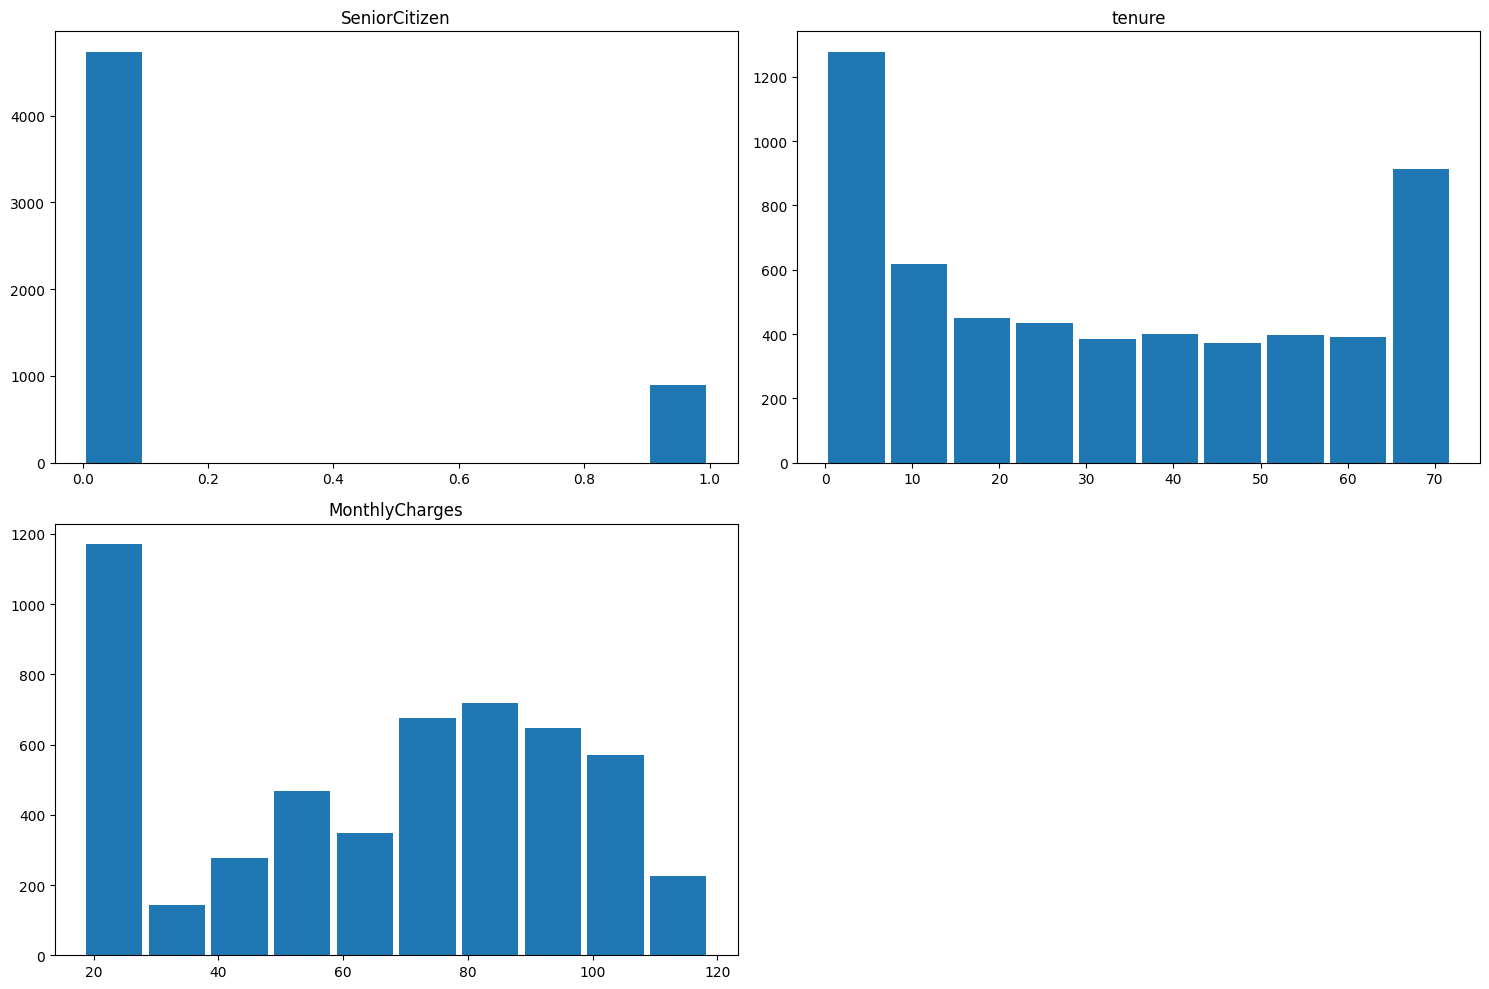

In [89]:
# Visualizing data distributions of the numerical columns
plt.figure(figsize = (15, 10))
for i, col in enumerate(train_data_num_cols,1):
  plt.subplot(2,2,i)
  plt.hist(train_data[col], rwidth = 0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [90]:
# Converting 'totalcharges' from object dtype to numeric
train_data['TotalCharges'] = pd.to_numeric(train_data['TotalCharges'], errors='coerce')
# errors = 'coerce' replaces " " with NaN

In [91]:
train_data_num_cols = train_data.select_dtypes(include = ['number']).columns

In [92]:
train_median = train_data['TotalCharges'].median()

In [93]:
train_data['TotalCharges'] = train_data['TotalCharges'].fillna(train_median)

In [94]:
median_monthly_charges = train_data['MonthlyCharges'].median()

In [95]:
train_data['MonthlyCharges'] = train_data['MonthlyCharges'].fillna(median_monthly_charges)

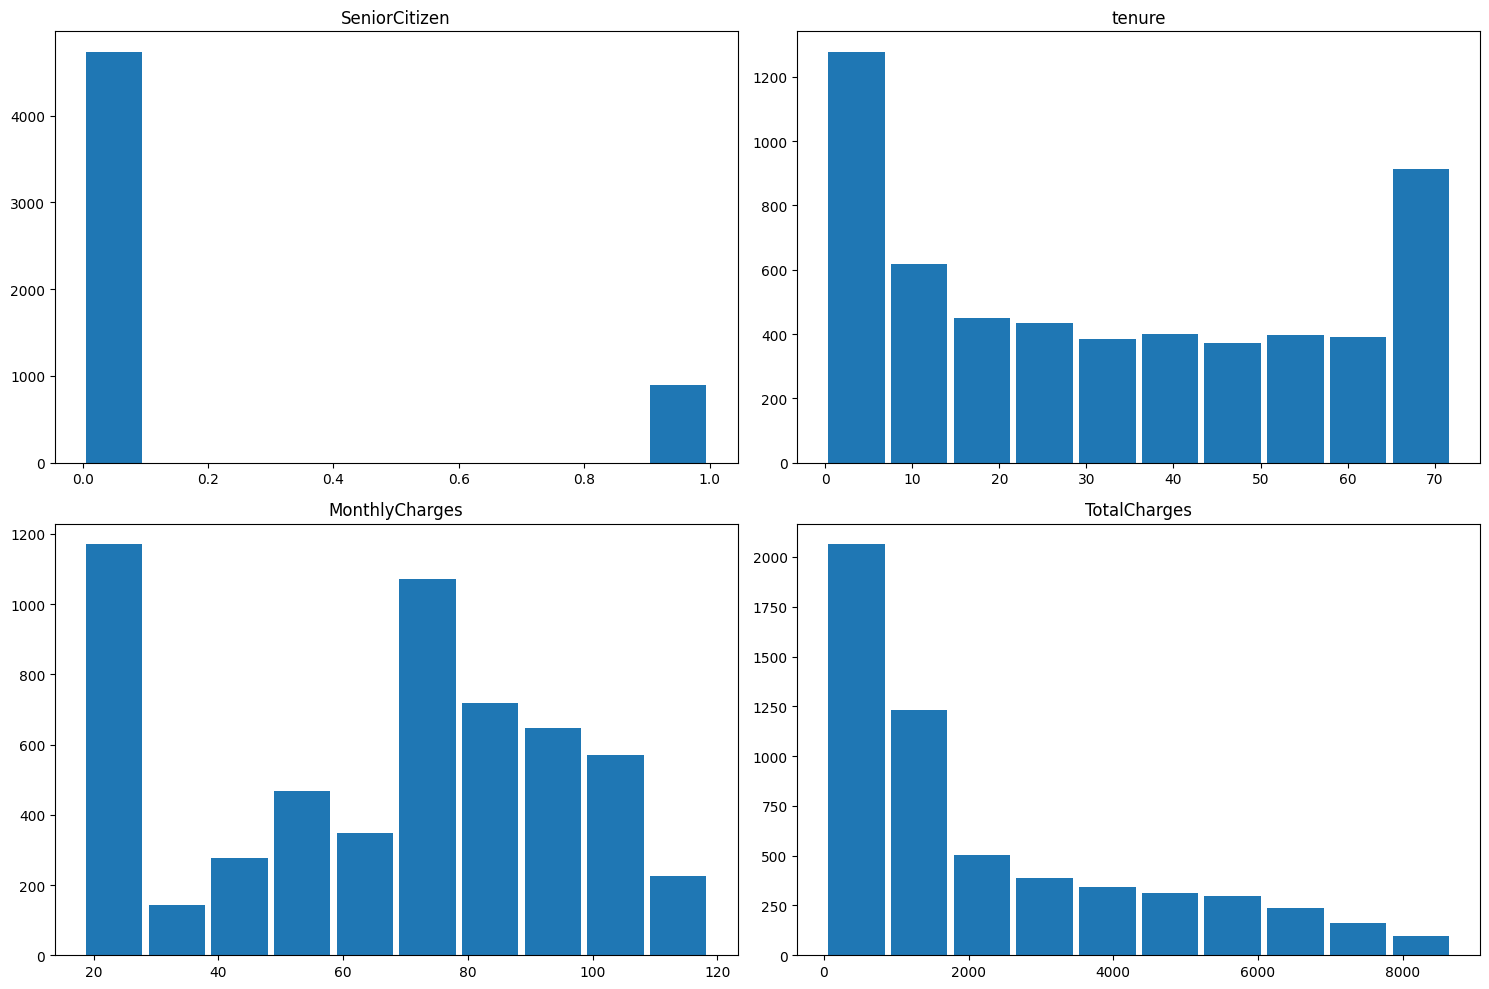

In [96]:
plt.figure(figsize = (15, 10))
for i, col in enumerate(train_data_num_cols,1):
  plt.subplot(2,2,i)
  plt.hist(train_data[col], rwidth = 0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [97]:
train_data.isna().sum() # After handling missing values in numerical columns

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [98]:
cols = ['gender', 'OnlineSecurity']

In [99]:
# Guessing the most common category is the statistically safest way to fill missing text
# data without skewing the dataset's existing distribution. So 'Mode' is used
train_modes = train_data[cols].mode().iloc[0]
train_data[cols] = train_data[cols].fillna(train_modes)

In [100]:
# After replacing categorical columns NA values
train_data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Correcting Data Types

In [101]:
test_data['TotalCharges'] = pd.to_numeric(test_data['TotalCharges'], errors='coerce')

In [102]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [103]:
# Filling NaN with median value of the train data
test_data['TotalCharges'] = test_data['TotalCharges'].fillna(train_median)

In [104]:
test_data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Handling Outliers

In [105]:
train_data_num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

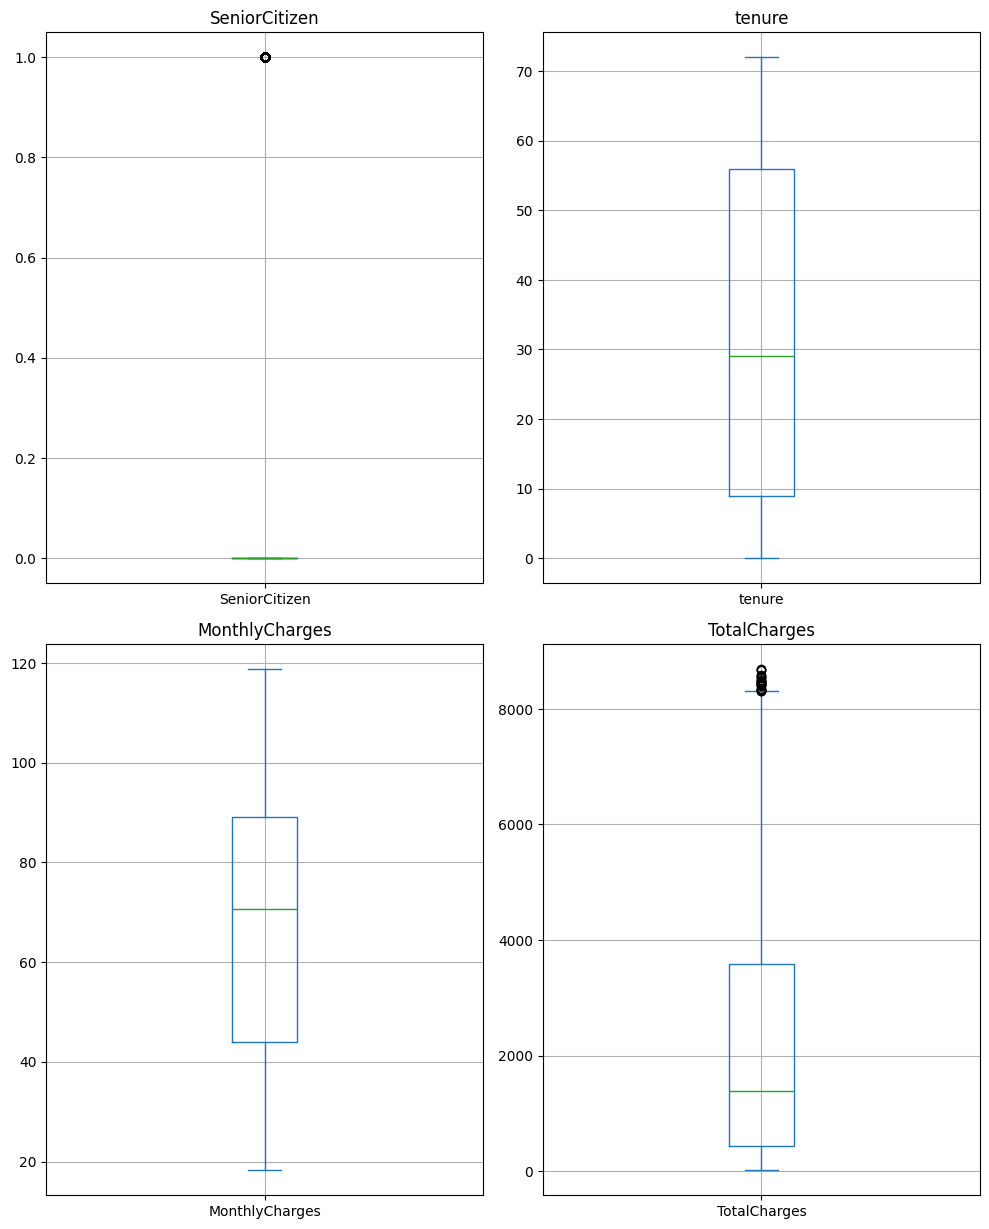

In [106]:
plt.figure(figsize=(10,55))
for i, col in enumerate(train_data_num_cols,1):
  plt.subplot(9,2,i)
  train_data[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [107]:
# We retain these outliers because they are not data entry errors, but rather represent our longest-tenured, highest paying customers.
# Removing or capping them would blind the model to the behavior patterns of the most profitable segment, which is critical for targeted retention.

## Removing Unwanted Columns

In [108]:
# corelation
corr_matrix = train_data[train_data_num_cols].corr(method='pearson')
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.022672,0.205024,0.101343
tenure,0.022672,1.000000,0.232216,0.796983
MonthlyCharges,0.205024,0.232216,1.000000,0.606911
TotalCharges,0.101343,0.796983,0.606911,1.000000


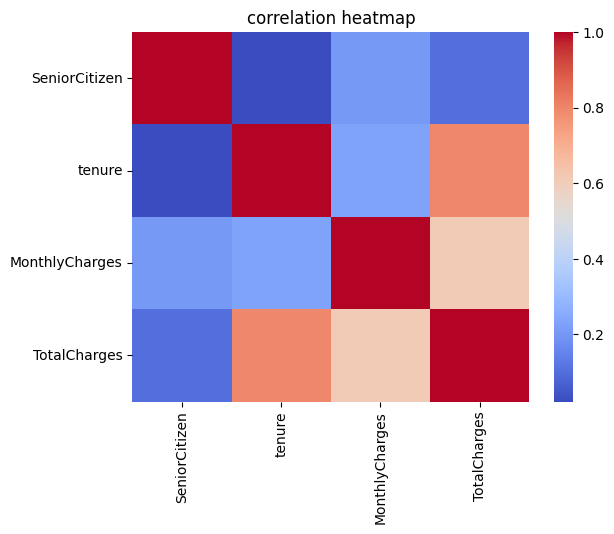

In [109]:
# ploting a heat map to visualize correlation
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [110]:
# Dropping the 'customerID' column as it holds no valuable information
train_data.drop('customerID', axis = 1, inplace = True)

In [111]:
# Same for the test data
test_data.drop('customerID', axis = 1, inplace = True)

In [112]:
# Removing the column due to low correlation
train_data.drop('SeniorCitizen', axis=1, inplace=True)
test_data.drop('SeniorCitizen', axis=1, inplace=True)

In [113]:
train_data_num_cols = train_data_num_cols.drop('SeniorCitizen')

## Scaling

In [114]:
train_data.describe()

,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000
mean,32.606851,65.490034,2238.250728
std,24.614976,29.020760,2216.294428
min,0.000000,18.250000,18.850000
25%,9.000000,44.000000,446.062500
50%,29.000000,70.650000,1396.450000
75%,56.000000,89.100000,3590.537500
max,72.000000,118.750000,8684.800000


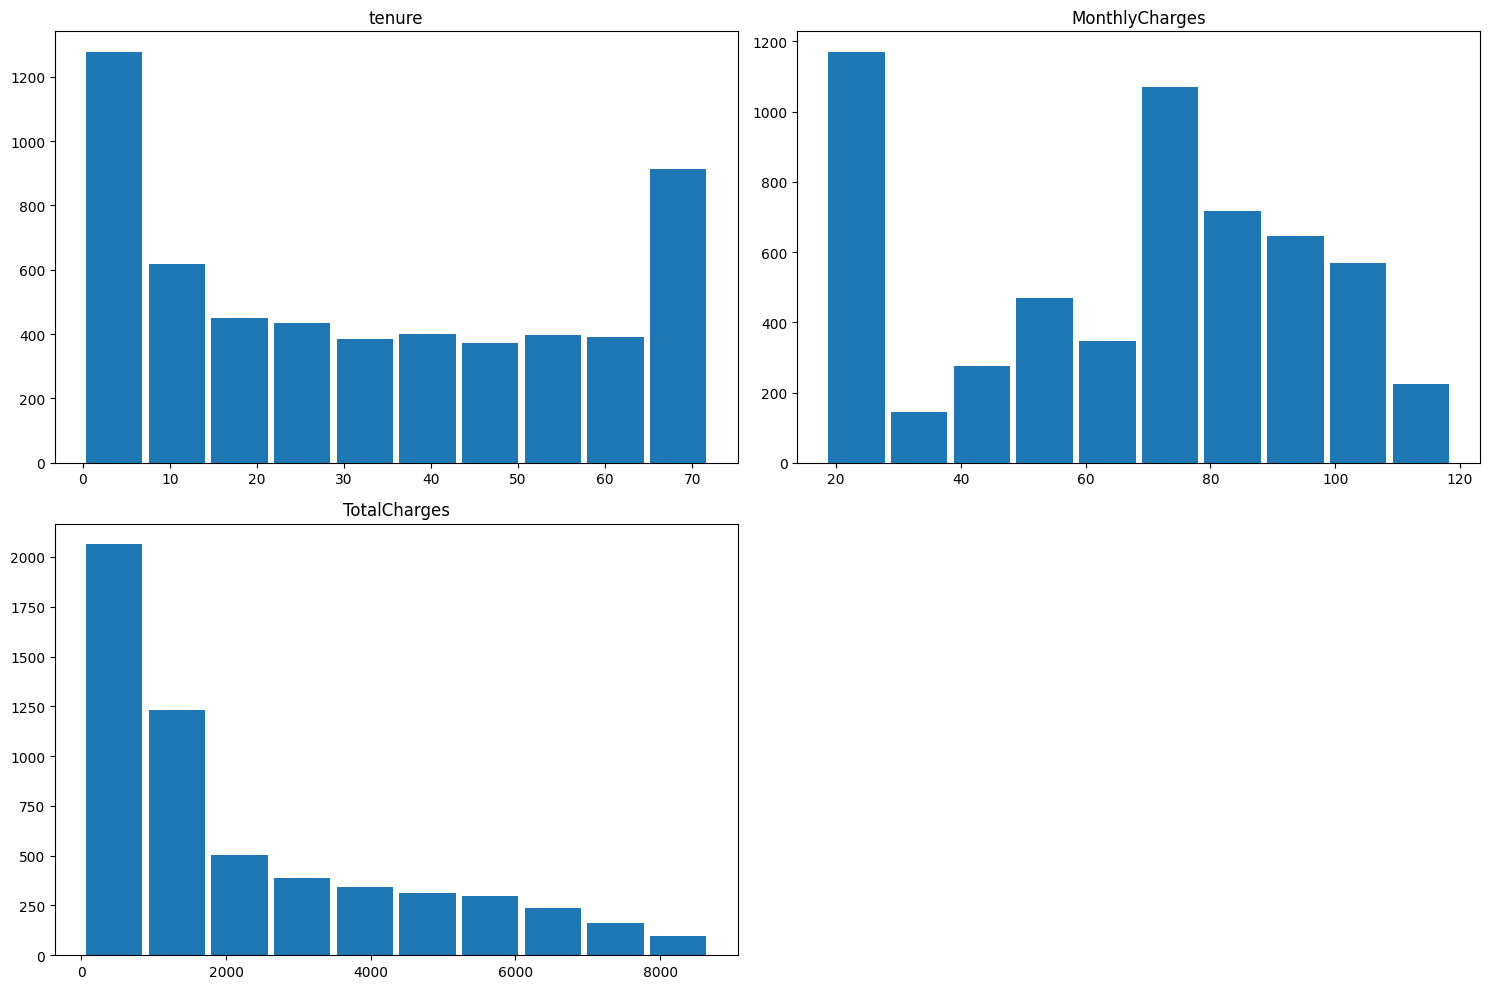

In [115]:
plt.figure(figsize = (15, 10))
for i, col in enumerate(train_data_num_cols,1):
  plt.subplot(2,2,i)
  plt.hist(train_data[col], rwidth = 0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [116]:
# Since the data does not follow bell curve, Min - Max scaler is used

In [130]:
scaler = MinMaxScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Customer Life Time Value']
train_data[cols_to_scale] = scaler.fit_transform(train_data[cols_to_scale])
test_data[cols_to_scale] = scaler.transform(test_data[cols_to_scale])

In [131]:
train_data.describe()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Customer Life Time Value
count,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,...,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.517039,0.487043,0.297125,0.452873,0.901846,0.594604,0.470050,0.256106,0.266951,0.098154,...,0.213525,0.388179,0.213525,0.390309,0.208023,0.242812,0.215832,0.335818,0.226837,0.269155
std,0.499754,0.499876,0.457032,0.341875,0.297549,0.491012,0.288764,0.255747,0.442406,0.297549,...,0.409832,0.487379,0.409832,0.487863,0.405929,0.428820,0.411435,0.472318,0.418824,0.262313
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.125000,1.000000,0.000000,0.256219,0.049298,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.048652
50%,1.000000,0.000000,0.000000,0.402778,1.000000,1.000000,0.521393,0.158967,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.167035
75%,1.000000,1.000000,1.000000,0.777778,1.000000,1.000000,0.704975,0.412152,1.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.449088
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Encoding

In [119]:
train_data_cat_cols = train_data_cat_cols.drop('customerID')

In [120]:
train_data[train_data_cat_cols]

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,Female,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,700.45,No
1,Female,No,No,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,961.40,No
2,Male,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,5581.05,No
3,Male,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),790.00,No
4,Female,Yes,Yes,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Male,No,No,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,5038.15,No
5630,Male,Yes,No,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,2965.75,No
5631,Male,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),1322.85,No
5632,Female,No,No,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),5555.30,No


In [121]:
for col in train_data_cat_cols:
  unique_values = train_data[col].unique()
  print(f"{col}: {unique_values}")

gender: ['Female' 'Male']
Partner: ['No' 'Yes']
Dependents: ['No' 'Yes']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'No phone service' 'Yes']
InternetService: ['No' 'DSL' 'Fiber optic']
OnlineSecurity: ['No internet service' 'No' 'Yes']
OnlineBackup: ['No internet service' 'No' 'Yes']
DeviceProtection: ['No internet service' 'Yes' 'No']
TechSupport: ['No internet service' 'Yes' 'No']
StreamingTV: ['No internet service' 'No' 'Yes']
StreamingMovies: ['No internet service' 'No' 'Yes']
Contract: ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: ['No' 'Yes']
PaymentMethod: ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges: [ 700.45  961.4  5581.05 ... 1322.85 5555.3  1381.8 ]
Churn: ['No' 'Yes']


In [122]:
# Label encoding for binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

le = LabelEncoder()

for col in binary_cols:
    train_data[col] = le.fit_transform(train_data[col])

    test_data[col] = le.transform(test_data[col])

In [123]:
train_data.head()

,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,35,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,20.75,700.45,0
1,0,0,0,28,0,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,1,Mailed check,35.75,961.40,0
2,1,0,0,56,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,0,Electronic check,98.60,5581.05,0
3,1,1,0,39,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,1,Bank transfer (automatic),20.45,790.00,0
4,0,1,1,43,0,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,1,Bank transfer (automatic),51.25,2151.60,0


In [124]:
test_data.head()

,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,1,1,40,1,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,81.20,3292.30,0
1,0,1,0,12,1,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,0,Electronic check,78.85,876.75,0
2,1,0,0,43,1,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,1,Electronic check,100.00,4211.55,1
3,1,0,0,72,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Electronic check,118.20,8547.15,0
4,0,0,0,10,0,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,0,Electronic check,36.25,374.00,0


In [125]:
# One Hot Encoding for multi output columns
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

train_data = pd.get_dummies(train_data, columns=multi_cols, drop_first=True, dtype=int)
test_data = pd.get_dummies(test_data, columns=multi_cols, drop_first=True, dtype=int)

In [126]:
train_data.head()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,35,1,0,20.75,700.45,0,0,...,0,1,0,1,0,1,0,0,0,1
1,0,0,0,28,0,1,35.75,961.40,0,1,...,1,0,0,0,0,0,0,0,0,1
2,1,0,0,56,1,0,98.60,5581.05,0,0,...,0,0,1,0,1,0,0,0,1,0
3,1,1,0,39,1,1,20.45,790.00,0,0,...,0,1,0,1,0,0,1,0,0,0
4,0,1,1,43,0,1,51.25,2151.60,0,1,...,1,0,1,0,0,1,0,0,0,0


In [127]:
test_data.head()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,1,1,40,1,1,81.20,3292.30,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,1,0,12,1,0,78.85,876.75,0,0,...,0,0,1,0,1,1,0,0,1,0
2,1,0,0,43,1,1,100.00,4211.55,1,0,...,1,0,1,0,1,1,0,0,1,0
3,1,0,0,72,1,1,118.20,8547.15,0,0,...,1,0,1,0,1,0,1,0,1,0
4,0,0,0,10,0,0,36.25,374.00,0,1,...,1,0,0,0,0,0,0,0,1,0


# Feature Engineering

## Customer Life Time Value

In [128]:
train_data['Customer Life Time Value'] = train_data['tenure'] * train_data['MonthlyCharges']
test_data['Customer Life Time Value'] = test_data['tenure'] * test_data['MonthlyCharges']

In [129]:
train_data.head(2)

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Customer Life Time Value
0,0,0,0,35,1,0,20.75,700.45,0,0,...,1,0,1,0,1,0,0,0,1,726.25
1,0,0,0,28,0,1,35.75,961.40,0,1,...,0,0,0,0,0,0,0,0,1,1001.00


# Data Splitting

In [132]:
X_train = train_data.drop('Churn', axis=1)
y_train = train_data['Churn']

In [133]:
X_test = test_data.drop('Churn', axis=1)
y_test = test_data['Churn']

# ML Model Building

## Logistic Regression

In [134]:
# Intialising
log_reg = LogisticRegression()
# Training the model
log_reg.fit(X_train, y_train)
# Prediction using the trained model
y_pred_log_reg = log_reg.predict(X_test)
# Evaluating Model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)

print(f"Accuracy of logistic regression: {log_reg_accuracy}")
print(f"Recall of logistic regression: {log_reg_recall}")
print(f"Precision of logistic regression: {log_reg_precision}")
print(f"F1 score of logistic regression: {log_reg_f1}")

Accuracy of logistic regression: 0.8112136266855926
Recall of logistic regression: 0.5534246575342465
Precision of logistic regression: 0.6622950819672131
F1 score of logistic regression: 0.6029850746268657


## SVM

In [135]:
# Intialising
svm = SVC()
# Training the model
svm.fit(X_train, y_train)
# Prediction using the trained model
y_pred_svm = svm.predict(X_test)
# Evaluating Model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print(f"Accuracy of Support Vector Machines: {svm_accuracy}")
print(f"Recall of Support Vector Machines: {svm_recall}")
print(f"Precision of Support Vector Machines: {svm_precision}")
print(f"F1 score of Support Vector Machines: {svm_f1}")

Accuracy of Support Vector Machines: 0.801277501774308
Recall of Support Vector Machines: 0.4849315068493151
Precision of Support Vector Machines: 0.6579925650557621
F1 score of Support Vector Machines: 0.5583596214511041


## Decision trees

In [136]:
# Intialising
decision_tree = DecisionTreeClassifier()
# Training the model
decision_tree.fit(X_train, y_train)
# Prediction using the trained model
y_pred_decision_tree = decision_tree.predict(X_test)
# Evaluating Model
decision_tree_accuracy = accuracy_score(y_test, y_pred_decision_tree)
decision_tree_recall = recall_score(y_test, y_pred_decision_tree)
decision_tree_precision = precision_score(y_test, y_pred_decision_tree)
decision_tree_f1 = f1_score(y_test, y_pred_decision_tree)

print(f"Accuracy of Decision Trees: {decision_tree_accuracy}")
print(f"Recall of Decision Trees: {decision_tree_recall}")
print(f"Precision of Decision Tress: {decision_tree_precision}")
print(f"F1 score of Decision Trees: {decision_tree_f1}")

Accuracy of Decision Trees: 0.730305180979418
Recall of Decision Trees: 0.5150684931506849
Precision of Decision Tress: 0.48081841432225064
F1 score of Decision Trees: 0.4973544973544973


# Fine Tuning

In [ ]:
#Recall is prioritized because the cost of a False Negative (losing a customers total lifetime value) is significantly higher than the cost of a False Positive

#This ensures the model captures the highest percentage of at risk revenue, making it the most effective "early warning" tool for business retention.

In [139]:
# Define the base model
# (Increasing max_iter ensures the math converges properly during tuning)
log_reg_base = LogisticRegression(max_iter=1000, random_state=42)

# Define the hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

# Initialize GridSearchCV
# We explicitly tell it to optimize for 'recall' to catch more churners
grid_search = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid,
    scoring='recall',
    cv=5, # 5-fold cross-validation to handle overfitting
)

# Train the grid search (This tests all 40 combinations)
grid_search.fit(X_train, y_train)

# Extract the best model and evaluate
best_log_reg = grid_search.best_estimator_
y_pred_tuned = best_log_reg.predict(X_test)

tuned_log_reg_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_log_reg_recall = recall_score(y_test, y_pred_tuned)
tuned_log_reg_precision = precision_score(y_test, y_pred_tuned)
tuned_log_reg_f1 = f1_score(y_test, y_pred_tuned)

# Print results
print("Best Parameters:", grid_search.best_params_)
print()
print(f"Accuracy: {tuned_log_reg_accuracy:.4f}")
print(f"Recall: {tuned_log_reg_recall:.4f}")
print(f"Precision: {tuned_log_reg_precision:.4f}")
print(f"F1 Score: {tuned_log_reg_f1:.4f}")

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}

Accuracy: 0.7331
Recall: 0.7808
Precision: 0.4905
F1 Score: 0.6025


In [140]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', random_state=42))
])

# Define the Parameter Grid
# C: Regularization, Gamma: Kernel coefficient
param_grid = {
    'svm__C': [1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01],
    'svm__kernel': ['rbf']
}

# Grid Search
grid_svm = GridSearchCV(svm_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

# Evaluate
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

tuned_svm_accuracy = accuracy_score(y_test, y_pred_svm)
tuned_svm_recall = recall_score(y_test, y_pred_svm)
tuned_svm_precision = precision_score(y_test, y_pred_svm)
tuned_svm_f1 = f1_score(y_test, y_pred_svm)

print(f"Best Params: {grid_svm.best_params_}")
print()
print(f"Accuracy: {tuned_svm_accuracy:.4f}")
print(f"Recall: {tuned_svm_recall:.4f}")
print(f"Precision: {tuned_svm_precision:.4f}")
print(f"F1 Score: {tuned_svm_f1:.4f}")

Best Params: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Accuracy: 0.7161
Recall: 0.7342
Precision: 0.4694
F1 Score: 0.5726


In [141]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

# Set up Grid Search (optimizing for recall)
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42), # <-- Fixed the missing comma here!
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Fit it to the training data
grid_search_dt.fit(X_train, y_train)

# Predict using the best model
best_dt = grid_search_dt.best_estimator_
y_pred_tuned_dt = best_dt.predict(X_test)

tuned_dt_accuracy = accuracy_score(y_test, y_pred_tuned_dt)
tuned_dt_recall = recall_score(y_test, y_pred_tuned_dt)
tuned_dt_precision = precision_score(y_test, y_pred_tuned_dt)
tuned_dt_f1 = f1_score(y_test, y_pred_tuned_dt)

# Evaluate
print(f"Best Params: {grid_search_dt.best_params_}")
print()
print(f"Accuracy: {tuned_dt_accuracy:.4f}")
print(f"Recall: {tuned_dt_recall:.4f}")
print(f"Precision: {tuned_dt_precision:.4f}")
print(f"F1 Score: {tuned_dt_f1:.4f}")

Best Params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Accuracy: 0.7147
Recall: 0.7863
Precision: 0.4697
F1 Score: 0.5881


In [142]:
print("--- LOGISTIC REGRESSION ---")
print(f"Accuracy of Logistic Regression (Baseline): {log_reg_accuracy}")
print(f"Recall of Logistic Regression (Baseline): {log_reg_recall}")
print(f"Precision of Logistic Regression (Baseline): {log_reg_precision}")
print(f"F1 score of Logistic Regression (Baseline): {log_reg_f1}")
print()
print(f"Accuracy of Logistic Regression (Tuned): {tuned_log_reg_accuracy}")
print(f"Recall of Logistic Regression (Tuned): {tuned_log_reg_recall}")
print(f"Precision of Logistic Regression (Tuned): {tuned_log_reg_precision}")
print(f"F1 score of Logistic Regression (Tuned): {tuned_log_reg_f1}")
print("\n")

print("--- DECISION TREES ---")
print(f"Accuracy of Decision Trees (Baseline): {decision_tree_accuracy}")
print(f"Recall of Decision Trees (Baseline): {decision_tree_recall}")
print(f"Precision of Decision Trees (Baseline): {decision_tree_precision}")
print(f"F1 score of Decision Trees (Baseline): {decision_tree_f1}")
print()
print(f"Accuracy of Decision Trees (Tuned): {tuned_dt_accuracy}")
print(f"Recall of Decision Trees (Tuned): {tuned_dt_recall}")
print(f"Precision of Decision Trees (Tuned): {tuned_dt_precision}")
print(f"F1 score of Decision Trees (Tuned): {tuned_dt_f1}")
print("\n")

print("--- SUPPORT VECTOR MACHINES (SVM) ---")
print(f"Accuracy of Support Vector Machines (Baseline): {svm_accuracy}")
print(f"Recall of Support Vector Machines (Baseline): {svm_recall}")
print(f"Precision of Support Vector Machines (Baseline): {svm_precision}")
print(f"F1 score of Support Vector Machines (Baseline): {svm_f1}")
print()
print(f"Accuracy of Support Vector Machines (Tuned): {tuned_svm_accuracy}")
print(f"Recall of Support Vector Machines (Tuned): {tuned_svm_recall}")

--- LOGISTIC REGRESSION ---
Accuracy of Logistic Regression (Baseline): 0.8112136266855926
Recall of Logistic Regression (Baseline): 0.5534246575342465
Precision of Logistic Regression (Baseline): 0.6622950819672131
F1 score of Logistic Regression (Baseline): 0.6029850746268657

Accuracy of Logistic Regression (Tuned): 0.7331440738112136
Recall of Logistic Regression (Tuned): 0.7808219178082192
Precision of Logistic Regression (Tuned): 0.4905335628227194
F1 score of Logistic Regression (Tuned): 0.6025369978858351


--- DECISION TREES ---
Accuracy of Decision Trees (Baseline): 0.730305180979418
Recall of Decision Trees (Baseline): 0.5150684931506849
Precision of Decision Trees (Baseline): 0.48081841432225064
F1 score of Decision Trees (Baseline): 0.4973544973544973

Accuracy of Decision Trees (Tuned): 0.7146912704045423
Recall of Decision Trees (Tuned): 0.7863013698630137
Precision of Decision Trees (Tuned): 0.469721767594108
F1 score of Decision Trees (Tuned): 0.5881147540983607


--- 

#Conclusion

## Conclusion & Business Recs

Focusing on the most generalizable models, Logistic Regression is the clear winner. Using an l1 penalty, liblinear solver, and balanced weights, it achieved a recall of 0.7781 and an accuracy of 0.7331. It outperformed the SVM, which only managed a 0.7370 recall. Since our main goal is catching as many potential churners as possible, the high recall of LogReg makes it the best fit.

##Business Recs:

Deploy the LogReg Model: It successfully identifies ~78% of the customers who are actually going to leave.

Keep Retention Cheap: Precision is at 0.4905, meaning about half of the people the model flags aren't actually going anywhere. Stick to low-cost retention strategies (like targeted emails or small discounts) so we don't waste money giving perks to people who were going to stay anyway.

Find the Root Cause: Because we used L1 regularization, the model zeroed out the useless features. We need to look at the remaining features with the highest coefficients to figure out why people are leaving in the first place, and fix those specific issues.